# 4 Neural Networks

Our goal is to make 4 neural nets:
1. We have already made the first, out encoder which is an MLP that takes us to 512 ChemNet space
2. An MLP that will take spectra and output toxicity. We also want to make an RF that will do the same
3. An MLP that will take ChemNet embeddings and output toxicity, again we already have a RF that does this, which limited success for unknown chemical compounds.
4. The most complicated, a condiotnal encoder that will intake Spectra and output 516 space, which one hot encoded EPA levels as additinal conditions. This has many further considerations since it will need to peicewise loss function. 

## Imports and Globally Used Functions

In [1]:
# Package imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [2]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

In [3]:
# Binning functions
# Binning the spectra data 
def bin_spectra_by_integer_mz(df):
    """
    Bins the spectra data by rounding m/z (column names) to the nearest integer,
    then sums intensities for duplicate integer bins.
    Assumes first column is SMILES, rest are m/z columns (floats).
    """
    smiles_col = df.columns[0]
    spectra = df.iloc[:, 1:]
    # Map each column to its integer bin
    int_mz = [int(round(float(c))) for c in spectra.columns]
    spectra.columns = int_mz
    # Group columns by integer m/z and sum
    binned = spectra.groupby(level=0, axis=1).sum()
    # Add the SMILES column back
    binned.insert(0, smiles_col, df[smiles_col])
    return binned

# Fill in the missing integer columns 
def fill_missing_integer_columns(df):
    """
    Ensures all integer columns from 1 to the maximum are present in the DataFrame.
    Missing columns are filled with zeros.
    Assumes the first column is the label (e.g., SMILES).
    """
    # Get the integer columns (skip the first column)
    int_cols = [col for col in df.columns[1:] if isinstance(col, int)]
    #min_col = min(int_cols)
    max_col = max(int_cols)
    all_int_cols = list(range(1, max_col + 1))
    # Find missing columns
    missing_cols = set(all_int_cols) - set(int_cols)
    # Add missing columns with zeros
    for col in missing_cols:
        df[col] = 0.0
    # Reorder columns: first column, then sorted integer columns
    ordered_cols = [df.columns[0]] + sorted(all_int_cols)
    df = df[ordered_cols]
    return df

In [4]:
# Cate's smiles to ChemNet embedding code
def get_chemnet_emb_from_smiles(smiles_list):
    """
    Get ChemNet embeddings from a list of SMILES strings.

    Parameters:
    smiles_list (list): List of SMILES strings.

    Returns:
    dict: A dictionary mapping each SMILES string to its corresponding ChemNet embedding.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    fcd = FCD(device, n_jobs=1)
    
    smiles_emb_dict = {}

    for smiles in smiles_list:
        try:
            emb = fcd.get_predictions([smiles])[0]
            smiles_emb_dict[smiles] = list(emb)
        except KeyError as e:
            if e == 'PropertyTable':
                smiles_emb_dict[smiles] = 'unknown'

    return smiles_emb_dict

In [5]:
# Define a function to assign EPA levels
def assign_epa_level(response):
    if response <= 50:
        return "EPA_level_1"
    elif response <= 500:
        return "EPA_level_2"
    elif response <= 5000:
        return "EPA_level_3"
    else:
        return "EPA_level_4"

## Initial Data upload and processing

In [6]:
# The 5/30 dataset with rat based toxicity data and groups
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# This will give us the subsets with all of the relevant information
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307
df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 


# Now since I have saved files of the binned specrtra I can simply call those
df3_QQpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
df3_QQneg_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQneg_spectra.csv")
df3_LTQOpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_LTQOpos_spectra.csv")
df3_QTOFpos_spectra = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QTOFpos_spectra.csv")


(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


## Spectra --> ChemNet Encoder

### Functions

In [7]:
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-1]

    #chem_encodings = spectra_dataset.iloc[:,-8:]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    #chem_encodings_tensor = torch.Tensor(chem_encodings.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

### Architecture

In [8]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 5

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss) and loss2 (toxicity loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training

In [9]:
# Training and validation dataset split 
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")
# Generalize the syntax
dataset =  df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

# Make a copy
# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()

# Save under correct names
train_data_df3_QQpos = train_data
test_data_df3_QQpos = test_data
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 681)
(579, 681)


In [10]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
combined_df3_QQpos = pd.concat([train_data_df3_QQpos, test_data_df3_QQpos], ignore_index=True)
super_testing_df3_QQpos = combined_df3_QQpos[combined_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
train_data_df3_QQpos = train_data_df3_QQpos[~train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()
test_data_df3_QQpos = test_data_df3_QQpos[~test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, train shape:", train_data_df3_QQpos.shape)
print("After removal, test shape:", test_data_df3_QQpos.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any left in train?", any(train_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))
print("Any left in test?", any(test_data_df3_QQpos['SMILES_spectra'].isin(smiles_to_remove)))

After removal, train shape: (564, 681)
After removal, test shape: (538, 681)
Super testing set shape: (86, 681)
Any left in train? False
Any left in test? False


In [11]:
# # Verification of the number of training and testing SMILES present
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())
# # Limitation of the number of training and testing spectra used
# num_smiles_limit = 10  # Change this value to use a different number of SMILES
# unique_smiles = train_data_df3_QQpos['SMILES_spectra'].unique()[:num_smiles_limit]
# train_data_df3_QQpos = train_data_df3_QQpos[train_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# test_data_df3_QQpos = test_data_df3_QQpos[test_data_df3_QQpos['SMILES_spectra'].isin(unique_smiles)].copy()
# # Verify the limitation
# print(train_data_df3_QQpos["SMILES_spectra"].nunique())
# print(test_data_df3_QQpos["SMILES_spectra"].nunique())

In [12]:
# Ensure we match the data correctly:
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos
val_data = test_data

In [13]:
# Encoder training
device = f.set_up_gpu()
# device = torch.device('cpu')

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
#sorted_chem_names = list(train_data.columns[-8:])
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
encoder_df3_QQpos = Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
model_df3_QQpos = train_model(
    model=encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)
x_val_df3_QQpos = x_val
x_train_df3_QQpos = x_train

Selected GPU ID: 0
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22681.0 MB
  Memory Used: 1536.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:0


PyTorch current device ID: 0
PyTorch current device name: NVIDIA GeForce RTX 4090


/tmp/ipykernel_1750943/3365415882.py:37: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)


Epoch [1/500]
   Training loss: 0.08750045133961572
   Validation loss: 0.01709849014878273
Epoch [2/500]
   Training loss: 0.07488226393858592
   Validation loss: 0.015793459489941597
Epoch [3/500]
   Training loss: 0.06731876234213512
   Validation loss: 0.014341105706989765
Epoch [4/500]
   Training loss: 0.06332832823197047
   Validation loss: 0.014070140197873116
Epoch [5/500]
   Training loss: 0.06104175001382828
   Validation loss: 0.013468446210026741
Epoch [6/500]
   Training loss: 0.05909681237406201
   Validation loss: 0.012930982746183872
Epoch [7/500]
   Training loss: 0.05705871722764439
   Validation loss: 0.012356272898614407
Epoch [8/500]
   Training loss: 0.05494181729025311
   Validation loss: 0.012555508874356747
Epoch [9/500]
   Training loss: 0.0523587746752633
   Validation loss: 0.012406640686094761
Epoch [10/500]
   Training loss: 0.049255346672402486
   Validation loss: 0.011232161894440651
Epoch [11/500]
   Training loss: 0.046106643974781036
   Validation lo

### Testing

In [14]:
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Encoder excecution df3_QQpos super testing
x_super_df3_QQpos = super_testing_df3_QQpos.iloc[:, 1:-1].values
x_super_tensor_df3_QQpos = torch.tensor(x_super_df3_QQpos, dtype=torch.float32).to(x_val_df3_QQpos.device)
encoder_df3_QQpos.eval()
with torch.no_grad():
    super_test_output_df3_QQpos = encoder_df3_QQpos(x_super_tensor_df3_QQpos)



## Spectra --> Toxicity MLP and Random Forest

### Processing

In [15]:
# Add the 'Response' column to df3_QQpos_spectra by mapping from the original df3_QQpos DataFrame
def add_response_column_to_spectra(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    return spectra_df

df3_QQpos_spectra = add_response_column_to_spectra(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

# Add EPA levels (one-hot) to df3_QQpos_spectra
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    df["EPA_level"] = df[response_col].apply(assign_func)
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    df.drop(columns=[response_col], inplace=True)
    return df

df3_QQpos_spectra_withEPA = add_epa_levels(df3_QQpos_spectra)
df3_QQpos_spectra_withEPA.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,674,675,676,677,678,679,EPA_level_1,EPA_level_2,EPA_level_3,EPA_level_4
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0,0


In [16]:
# Remove the specified SMILES from the train and test sets,
# and collect them into a new DataFrame called super_testing_df3_QQpos

smiles_to_remove = ['CCCSP(=O)(OCC)SCCC', 'C#CCN(C)Cc1ccccc1', 'C1=CC(=CC=N1)C1=CC=NC=C1', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'C(NC1=NC=NC2=C1N=CN2C1CCCCO1)C1=CC=CC=C1', 'CC(C)N(CC1=CC=CC=C1)C(=O)C(C)(C)C', 'NC(=S)NC1=CC=CC=C1', 
                    'CC(C)(C)C1=CC(=CC(=C1O)C(C)(C)C)[N+]([O-])=O', 'CC(C)(C)C1=CC=C(C=C1)C(O)=O', 'C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1', 
                    'CC(=C)C(=O)NC1=CC=C(Cl)C(Cl)=C1', 'CC(C)(C1=CC(Cl)=C(O)C(Cl)=C1)C1=CC(Cl)=C(O)C(Cl)=C1', 
                    'CCC(=O)N(C1CCN(CCC2=CC=CC=C2)CC1)C1=CC=CC=C1', 'CC(=O)N1CCN(CC1)C1=CC=C(OC[C@H]2CO[C@@](CN3C=CN=C3)(O2)C2=CC=C(Cl)C=C2Cl)C=C1', 
                    'CC(C)(C)C(=O)C(OC1=CC=C(Cl)C=C1)N1C=CN=C1', 'C1=CN(C=N1)C(C1=CC=CC=C1)C1=CC=C(C=C1)C1=CC=CC=C1', 'CC(=O)OCC[N+](C)(C)C', 
                    'CC(=O)NC1=CC=C(C=C1)S(=O)(=O)NC1=NOC(C)=C1', 'C1CCC(CC1)NC1CCCCC1', 'CC(CN1CCN(CCOCCO)CC1)CN1C2=CC=CC=C2SC2=CC=CC=C12', 
                    'CC(=O)OCC(COC(C)=O)OC(C)=O', 'CC(C)N(C(=O)CCl)c1ccccc1', 'CC1=C(C)N=C(NS(=O)(=O)C2=CC=C(N)C=C2)O1']

# Combine train and test to extract all rows with those SMILES
super_testing_df3_QQpos = df3_QQpos_spectra_withEPA[df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()

# Remove those SMILES from train and test sets
df3_QQpos_spectra_withEPA = df3_QQpos_spectra_withEPA[~df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)].copy()

print("After removal, shape:", df3_QQpos_spectra_withEPA.shape)
print("Super testing set shape:", super_testing_df3_QQpos.shape)
print("Any leff?", any(df3_QQpos_spectra_withEPA['SMILES_spectra'].isin(smiles_to_remove)))


After removal, shape: (1218, 684)
Super testing set shape: (89, 684)
Any leff? False


### Random Forest

In [17]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = df3_QQpos_spectra_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in df3_QQpos_spectra_withEPA.columns
    if col not in ['SMILES'] + [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in df3_QQpos_spectra_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1     24
EPA_level_2    239
EPA_level_3    720
EPA_level_4    235
dtype: int64


In [18]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = df3_QQpos_spectra_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = df3_QQpos_spectra_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

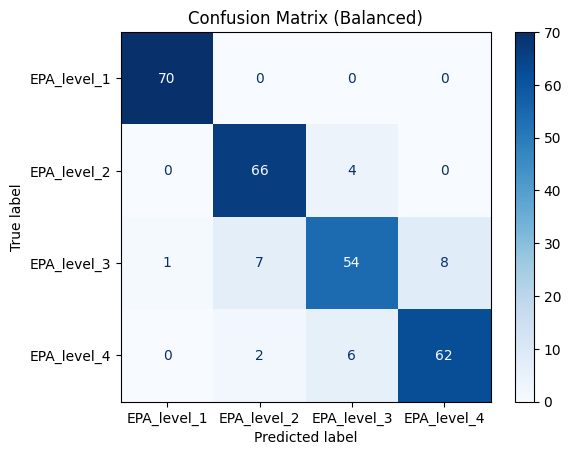

In [19]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### MLP Architecture

In [32]:
epochs=1000
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 10

#%%
# Everything below this line SHOULD be able to run without modification
class SpecToxMLP(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### MLP data processing

In [33]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

In [34]:
# Add the 'Response' and 'log_response' columns to df3_QQpos_spectra
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

In [35]:
# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data_df3_QQpos = add_response_and_log_response(train_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')
test_data_df3_QQpos = add_response_and_log_response(test_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')

# Make a copy
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 683)
(579, 683)


In [36]:
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

### MLP training

In [37]:
# MLP training
device = f.set_up_gpu()
# Training set
y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
SpecToxMLP_df3_QQpos = SpecToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
SpecToxMLP_model_df3_QQpos = train_model(
    model=SpecToxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22266.0 MB
  Memory Used: 1950.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/1000]
   Training loss: 55.73538665771484
   Validation loss: 11.476823806762695
Epoch [2/1000]
   Training loss: 54.207008361816406
   Validation loss: 10.103922843933105
Epoch [3/1000]
   Training loss: 47.15468406677246
   Validation loss: 7.82686185836792
Epoch [4/1000]
   Training loss: 19.88691053390503
   Validation loss: 1.2683734893798828
Epoch [5/1000]
   Training loss: 11.102627515792847
   Validation loss: 2.364766836166382
Epoch [6/1000]
   Training loss: 7.606058740615845
   Validation loss: 0.900340735912323
Epoch [7/1000]
   Training loss: 5.617476892471314
   Validation loss: 0.9357733130455017
Epoch [8/1000]
   Training loss: 4.2512072086334225
   Validation loss: 0.47934994101524353
Epoch [9/1000]
   Training loss: 3.204829239845276


## ChemNet --> Toxicity MLP and Random Forest

### Processing to/of ChemNet Embeddings

In [ ]:
# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos['SMILES_spectra']


In [ ]:
# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Example usage for each output DataFrame:
test_output_df3_QQpos = add_response_column(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_column(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')


In [ ]:
def add_epa_levels(df, response_col='Response', assign_func=assign_epa_level):
    """
    Adds EPA level columns (one-hot) to the DataFrame based on the response column.
    Removes the original response column.
    """
    df = df.copy()
    # Assign EPA levels
    df["EPA_level"] = df[response_col].apply(assign_func)
    # One-hot encode
    df = pd.get_dummies(df, columns=["EPA_level"], prefix='', prefix_sep='')
    # Convert boolean columns to int
    epa_cols = [col for col in df.columns if str(col).startswith("EPA_level_")]
    df[epa_cols] = df[epa_cols].astype(int)
    # Remove the Response column
    df.drop(columns=[response_col], inplace=True)
    return df

# Example usage for all your DataFrames:
test_output_df3_QQpos_withEPA = add_epa_levels(test_output_df3_QQpos)
train_output_df3_QQpos_withEPA = add_epa_levels(train_output_df3_QQpos)

In [ ]:
# # Process encoder outputs for all 4 super test sets
# # QQpos
# super_test_output_df3_QQpos_np = super_test_output_df3_QQpos.cpu().numpy()
# super_test_output_df3_QQpos_df = pd.DataFrame(
#     super_test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(super_test_output_df3_QQpos_np.shape[1])]
# )
# super_test_output_df3_QQpos_df['SMILES_spectra'] = super_testing_df3_QQpos['SMILES_spectra'].values

# # Add the 'Response' column using the original dataframes
# super_test_output_df3_QQpos_df = add_response_column(super_test_output_df3_QQpos_df, df3_QQpos, smiles_col='SMILES_spectra')

# # Add EPA levels (one-hot) and remove 'Response'
# super_test_output_df3_QQpos_withEPA = add_epa_levels(super_test_output_df3_QQpos_df)


In [ ]:
# # Make the dataframes that we will use a train set, a test set, and a combined set
# train_concat = pd.concat([
#     train_output_df3_QQpos_withEPA,
#     train_output_df3_QQneg_withEPA,
#     train_output_df3_QTOFpos_withEPA,
#     train_output_df3_LTQOpos_withEPA
# ], ignore_index=True)

# test_concat = pd.concat([
#     test_output_df3_QQpos_withEPA,
#     test_output_df3_QQneg_withEPA,
#     test_output_df3_QTOFpos_withEPA,
#     test_output_df3_LTQOpos_withEPA
# ], ignore_index=True)

# combined_concat = pd.concat([train_concat, test_concat], ignore_index=True)

# print("Train shape:", train_concat.shape)
# print("Test shape:", test_concat.shape)
# print("Combined shape:", combined_concat.shape)

# # Super test concatonation
# super_test_concat = pd.concat([
#     super_test_output_df3_QQpos_withEPA,
#     super_test_output_df3_QQneg_withEPA,
#     super_test_output_df3_QTOFpos_withEPA,
#     super_test_output_df3_LTQOpos_withEPA
# ], ignore_index=True)

### Random Forest

In [ ]:
# Count the number of samples in each EPA level in your dataset
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]

# Sum each EPA level column to get counts
epa_counts = test_output_df3_QQpos_withEPA[epa_level_cols].sum().astype(int)
print("EPA level counts in test_output_df3_QQpos_withEPA:")
print(epa_counts)

EPA level counts in test_output_df3_QQpos_withEPA:
EPA_level_1      9
EPA_level_2    102
EPA_level_3    302
EPA_level_4    125
dtype: int64


In [ ]:
# Identify embedding columns and EPA level columns
embedding_cols = [
    col for col in test_output_df3_QQpos_withEPA.columns
    if col not in ['SMILES'] + [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
]
epa_level_cols = [col for col in test_output_df3_QQpos_withEPA.columns if str(col).startswith('EPA_level_')]
# Define the EPA levels in numerical order
epa_order = ["EPA_level_1", "EPA_level_2", "EPA_level_3", "EPA_level_4"]


In [ ]:
# Balanced 4 way Random Forest Classifier
# Prepare features (X) and labels (y) as before
X = test_output_df3_QQpos_withEPA[embedding_cols].select_dtypes(include=[np.number])
X.columns = X.columns.astype(str)
y = test_output_df3_QQpos_withEPA[epa_level_cols].idxmax(axis=1)

# Set the target number of samples per class
target_count = 350
class_counts = dict(Counter(y))
sampling_strategy = {cls: min(target_count, class_counts[cls]) for cls in class_counts}
# First undersample to at most 30 per class
rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=15)
X_under, y_under = rus.fit_resample(X, y)

# Now oversample to exactly 30 per class
sampling_strategy = {cls: target_count for cls in class_counts}
ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=15)
X_balanced, y_balanced = ros.fit_resample(X_under, y_under)

# Train/test split
X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=15, stratify=y_balanced
)

# Train Random Forest
rf_bal = RandomForestClassifier(n_estimators=100, random_state=15)
rf_bal.fit(X_train_bal, y_train_bal)

# Predict and evaluate
y_pred_bal = rf_bal.predict(X_test_bal)
#print(confusion_matrix(y_test_bal, y_pred_bal))

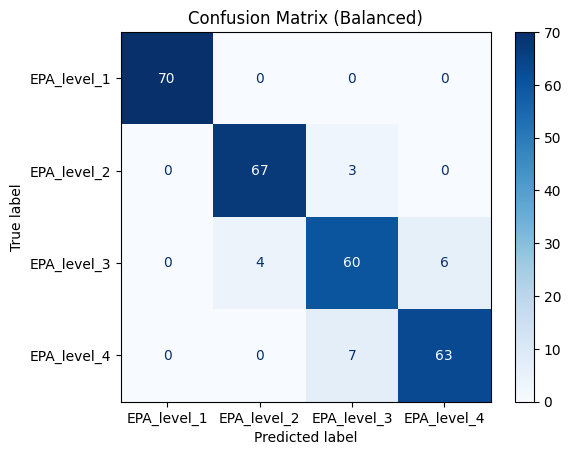

In [ ]:
# Print and plot confusion matrix in numerical order
cm = confusion_matrix(y_test_bal, y_pred_bal, labels=epa_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=epa_order)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Balanced)")
plt.show()

### Neural Network Data Processing

In [ ]:
# First we will need to adjust the data so that we have included the log of response.

# Run the encoder
# Encoder excecution df3_QQpos
encoder_df3_QQpos.eval()
with torch.no_grad():
    test_output_df3_QQpos = encoder_df3_QQpos(x_val_df3_QQpos)  

with torch.no_grad():
    train_output_df3_QQpos = encoder_df3_QQpos(x_train_df3_QQpos)

# Conversion of the outputs to numpy arrays then to pandas dataframes
test_output_df3_QQpos_np = test_output_df3_QQpos.cpu().numpy()
train_output_df3_QQpos_np = train_output_df3_QQpos.cpu().numpy()

# Convert to pandas DataFrames
test_output_df3_QQpos = pd.DataFrame(test_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(test_output_df3_QQpos_np.shape[1])])
train_output_df3_QQpos = pd.DataFrame(train_output_df3_QQpos_np, columns=[f'Embedding Float {i+1}' for i in range(train_output_df3_QQpos_np.shape[1])])

# Add the 'SMILES_spectra' column to the test and train outputs using the indices from the original test dataframes
test_output_df3_QQpos['SMILES_spectra'] = test_data_df3_QQpos_copy['SMILES_spectra']
train_output_df3_QQpos['SMILES_spectra'] = train_data_df3_QQpos_copy['SMILES_spectra']

# Add the 'Response' values to the test and train outputs
def add_response_column(output_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds a 'Response' column to output_df by mapping from original_df using the SMILES column.
    """
    # Create mapping from SMILES to Response
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    output_df['Response'] = output_df[smiles_col].map(smiles_to_response)
    return output_df

# Add the response column
test_output_df3_QQpos = add_response_column(test_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')
train_output_df3_QQpos = add_response_column(train_output_df3_QQpos, df3_QQpos, smiles_col='SMILES_spectra')

# Take the log of the response column and save it  as log_response, a new column
test_output_df3_QQpos['log_response'] = np.log(test_output_df3_QQpos['Response'])
train_output_df3_QQpos['log_response'] = np.log(train_output_df3_QQpos['Response'])

# Add an index for bette integration into the MLP algorithm
test_output_df3_QQpos['index'] = test_output_df3_QQpos.index
train_output_df3_QQpos['index'] = train_output_df3_QQpos.index

In [ ]:
test_output_df3_QQpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.287403,0.061449,-0.155495,-0.155417,-0.040868,0.224595,-0.066064,-0.324200,-0.299324,0.047215,...,-0.005525,0.066902,-0.057029,0.303307,0.038701,-0.195539,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,0.064008,0.043513,0.297873,0.502233,-0.261255,1.179584,-0.751799,0.115446,-0.220698,0.469878,...,-0.172887,-0.065699,0.507396,-0.628445,-0.006611,-0.045546,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.271794,0.051475,-0.066188,-0.414789,-0.018859,0.092313,-0.112395,-0.356583,-0.395282,-0.048030,...,-0.003640,-0.063742,-0.108593,0.744284,0.196519,-0.158217,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,-0.096092,0.127071,0.187571,0.401577,-0.228870,0.951673,-0.808373,0.023463,-0.163549,0.316206,...,-0.230192,-0.037089,0.286037,-0.617652,-0.053451,-0.123978,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,-0.160811,0.013014,-0.015635,-0.002583,-0.036274,0.109243,-0.248537,-0.127441,-0.181809,-0.496239,...,-0.450858,-0.179685,0.100283,-0.254472,0.089940,-0.332838,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


In [ ]:
train_output_df3_QQpos.head()

,Embedding Float 1,Embedding Float 2,Embedding Float 3,Embedding Float 4,Embedding Float 5,Embedding Float 6,Embedding Float 7,Embedding Float 8,Embedding Float 9,Embedding Float 10,...,Embedding Float 507,Embedding Float 508,Embedding Float 509,Embedding Float 510,Embedding Float 511,Embedding Float 512,SMILES_spectra,Response,log_response,index
0,-0.110773,-0.003277,-0.019084,-0.095316,-0.031662,0.044071,-0.251076,-0.156605,-0.217631,-0.572186,...,-0.497814,-0.138137,0.001505,-0.222895,0.057330,-0.345559,C#CCN(C)Cc1ccccc1,273.642508,5.611823,0
1,-0.115825,0.006166,-0.024043,-0.109110,-0.047114,0.057443,-0.250998,-0.150306,-0.204833,-0.572577,...,-0.510282,-0.148725,0.025904,-0.230489,0.053482,-0.358345,C#CCN(C)Cc1ccccc1,273.642508,5.611823,1
2,-0.116201,-0.001412,-0.027819,-0.106023,-0.036906,0.034709,-0.242535,-0.159687,-0.203286,-0.551508,...,-0.490330,-0.146955,0.015097,-0.206807,0.062805,-0.342027,C#CCN(C)Cc1ccccc1,273.642508,5.611823,2
3,-0.112512,-0.002072,-0.019059,-0.100181,-0.044283,0.047980,-0.238147,-0.165711,-0.201113,-0.553377,...,-0.499562,-0.144391,0.012542,-0.219177,0.063455,-0.343961,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,3
4,-0.116386,0.001855,-0.021550,-0.111506,-0.039827,0.050562,-0.243991,-0.158519,-0.211761,-0.535459,...,-0.502159,-0.138379,0.013241,-0.212113,0.062326,-0.345270,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,5000.000000,8.517193,4


### Neural Network Architecture

In [ ]:
# The genreal architecture of the MLP will be the same as that of the encoder, the main difference between the two is that the MLP will 
# have a 1 dimensional output, the true Response values of each SMILES, and we will use those SMILES to track which repsonse value belongs 
# with each Chemical.
# We will also adjust the input so that we have the log(response) rather than just response as our varaible of interest.

epochs=1000
lr=0.0001
criterion=nn.MSELoss()
output_size = 1
num_layers = 10

#%%
# Everything below this line SHOULD be able to run without modification
class ToxMLP(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_log_tox = model(batch)
            loss = criterion(batch_predicted_log_tox, true_log_tox)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion(val_batch_predicted_tox, val_true_tox)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model

### Neural Network Data Prep

In [ ]:
def create_dataset_tensors_tox(spectra_dataset,device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-4]

    # create tensors of spectra, true toxicity values, and chemical name encodings for train and val
    #chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return log_tox_tensor, spectra_tensor, spectra_indices_tensor

### Training of the MLP

In [ ]:
# MLP training
device = f.set_up_gpu()
# Name the dataset I use correctly
train_data = train_output_df3_QQpos
val_data = test_output_df3_QQpos

# Training set
y_train, x_train, train_indices_tensor = create_dataset_tensors_tox(
    train_data, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val, x_val, val_indices_tensor = create_dataset_tensors_tox(
    val_data, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train, train_indices_tensor)
val_data = TensorDataset(x_val, y_val, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
toxMLP_df3_QQpos = ToxMLP(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
MLP_model_df3_QQpos = train_model(
    model=toxMLP_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion=criterion,
    device=device
)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 22132.0 MB
  Memory Used: 2084.0 MB
  GPU Load: 0.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090
Epoch [1/1000]
   Training loss: 55.12935087415907
   Validation loss: 13.247170448303223
Epoch [2/1000]
   Training loss: 54.84441714816623
   Validation loss: 12.70559024810791
Epoch [3/1000]
   Training loss: 54.78143607245551
   Validation loss: 13.42491340637207
Epoch [4/1000]
   Training loss: 54.355275048149956
   Validation loss: 12.8119535446167
Epoch [5/1000]
   Training loss: 53.64938396877713
   Validation loss: 12.621760368347168
Epoch [6/1000]
   Training loss: 51.46720419989692
   Validation loss: 11.568204879760742
Epoch [7/1000]
   Training loss: 41.55066935221354
   Validation loss: 7.448864459991455
Epoch [8/1000]
   Training loss: 13.175481213463677
   Validation loss: 1.7383809089660645
Epoch [9/1000]
   Training loss: 6.807392650180393
   

## Spectra --> ChemNet AND Toxicity Conditional Encoder

### Architecture

In [ ]:
batch_size = 64
epochs=500
lr=0.0001
criterion1=nn.MSELoss()
criterion2=nn.MSELoss()
output_size = 513
num_layers = 8

#%%
# Encoder architecture (With Validation Set)
class Cond_Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model(model, train_data, val_data, epochs, learning_rate, criterion1, criterion2, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, true_log_tox, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)
            true_log_tox = true_log_tox.to(device)

            optimizer.zero_grad()
            batch_predicted_combined = model(batch) # Take the first 512 for criterion 1 and the last for criterion 2, look up to make sure i only apply the loss to the subset of the model
            
            # Embedding Loss
            batch_predicted_embeddings = batch_predicted_combined[:, :512]
            loss1 = criterion1(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss)
            loss1.backward()
            optimizer.step()
            running_loss += loss1.item()

            # Response Loss
            batch_predicted_log_tox = batch_predicted_combined[:, 512:]
            loss2 = criterion2(batch_predicted_log_tox, true_log_tox) # loss2 (toxicity loss)
            loss2.backward()
            optimizer.step()
            running_loss += loss2.item()
        average_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, val_true_tox, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)
                val_true_tox = val_true_tox.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion1(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss1.item()

                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_tox.to(device)

                val_batch_predicted_tox = model(val_batch)

                val_loss = criterion2(val_batch_predicted_tox, val_true_tox)
                val_loss += loss2.item()
        average_val_loss = val_loss / len(val_loader)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


### Training and Testing set construction

In [ ]:
# Training and validation dataset split we need to add in response to the spectra.
df3_QQpos_spectra= pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/binned_df3_QQpos_spectra.csv")
name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

In [ ]:
# Add the 'Response' and 'log_response' columns to df3_QQpos_spectra
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

df3_QQpos_spectra = add_response_and_log_response(df3_QQpos_spectra, df3_QQpos, smiles_col='SMILES_spectra')

In [ ]:
df3_QQpos_spectra.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,672,673,674,675,676,677,678,679,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823


In [ ]:
# Generalize the syntax
dataset = df3_QQpos_spectra

# Count occurrences of each SMILES_spectra and keep only SMILES_spectra with at least 4 entries
counts = dataset['SMILES_spectra'].value_counts()
valid_smiles = counts[counts >= 4].index
filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()

train_indices = []
test_indices = []

for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
    idx = group.index.tolist()
    n = len(idx)
    np.random.shuffle(idx)  # shuffle for randomness
    split = n // 2
    test_idx = idx[:split]
    train_idx = idx[split:]
    # If odd, train gets the extra
    train_indices.extend(train_idx)
    test_indices.extend(test_idx)

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add an 'index' column 
train_data['index'] = train_data.index
test_data['index'] = test_data.index

print(train_data.shape)
print(test_data.shape)

train_data_df3_QQpos = add_response_and_log_response(train_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')
test_data_df3_QQpos = add_response_and_log_response(test_data_df3_QQpos_copy, df3_QQpos, smiles_col='SMILES_spectra')

# Make a copy
train_data = train_data_df3_QQpos
test_data = test_data_df3_QQpos

# Make a copy
train_data_df3_QQpos_copy = train_data.copy()
test_data_df3_QQpos_copy = test_data.copy()
# Load val_data
val_data = test_data

# # train_data = pd.read_csv("/") 
# # val_data = pd.read_csv(" ") 

(609, 683)
(579, 683)


In [ ]:
test_data_df3_QQpos.head()

,SMILES_spectra,1,2,3,4,5,6,7,8,9,...,673,674,675,676,677,678,679,index,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,273.642508,5.611823
3,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,5000.000000,8.517193
4,C(NC1=C2N=CN=C2N=CN1)C1=CC=CO1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,5000.000000,8.517193


In [ ]:
def create_dataset_tensors_emb_tox(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):

    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true embeddings, true toxicity values, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, log_tox_tensor, spectra_tensor, spectra_indices_tensor 

In [ ]:

# Define these in the talk
# Encoders
# Conditional encoders = Combination of encoder and regressor done at the same time
# Regressors
# 2 kinds of regressors
    # Type 1 = Input is a spectra
    # Type 2 = Input is an embedding
# Experiments 
    # Experiment A - What is the accuracy of a type 1 regressor?
    # Experiment B - What is the accuracy of an encoder followed by a type 2 regressor?
    # Experiment C - What is the accuracy of a conditional encoder? (Remember training an cond enc requires training both the encoder and the 
    # regression but testing it may only require testing the regression).

# Most of the stuff so far has been Experiment B. We have our first Experiment A (RF), and it worked better than we expected. Is that because 
# Experiment A are essentially the same as Experiment B? :( Not our working hypothesis! But it is what we seem to show with our preliminary example.

# Defining terms -> Experiments -> Which works best? 
# Code for Experiment C is not done yet! It's tricky. 

# If A is as good as B and C then this problem is not as hard as advertised. It seems that with the data that we have right now we don't need anything 
# all that fancy.

# MLP training
device = f.set_up_gpu()
# Training set
y_train_emb, y_train_tox, x_train, train_indices_tensor = create_dataset_tensors_emb_tox(
    train_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del train_data

# Validation set
y_val_emb, y_val_tox, x_val, val_indices_tensor = create_dataset_tensors_emb_tox(
    val_data, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
del val_data

train_data = TensorDataset(x_train, y_train_emb, y_train_tox, train_indices_tensor)
val_data = TensorDataset(x_val, y_val_emb, y_val_tox, val_indices_tensor)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
#%%
cond_encoder_df3_QQpos = Cond_Encoder(input_size=x_train.shape[1], output_size=output_size, num_layers=num_layers).to(device)

#%%
cond_encoder_model_df3_QQpos = train_model(
    model=cond_encoder_df3_QQpos,
    train_data=train_loader,
    val_data=val_loader,
    epochs=epochs,
    learning_rate=lr,
    criterion1=criterion1,
    criterion2=criterion2,
    device=device
)

Selected GPU ID: 1
  Name: NVIDIA GeForce RTX 4090
  Memory Free: 21626.0 MB
  Memory Used: 2590.0 MB
  GPU Load: 6.00%
Current device ID:  cuda:1
PyTorch current device ID: 1
PyTorch current device name: NVIDIA GeForce RTX 4090


/home/dlipsey/.local/lib/python3.8/site-packages/torch/nn/modules/loss.py:538: UserWarning: Using a target size (torch.Size([64, 512])) that is different to the input size (torch.Size([64, 513])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


RuntimeError: The size of tensor a (513) must match the size of tensor b (512) at non-singleton dimension 1